In [ ]:

from google.colab import drive
drive.mount('/content/drive')


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, log_loss
)



base_path = "/content/drive/MyDrive/TFG"

train_csv = base_path + "/df_train_clean.csv"
valid_csv = base_path + "/df_valid_clean.csv"

train_images_path = "/content/train_clean_images"
valid_images_path = "/content/valid_clean_images"

# Carpeta donde estaba guardado el modelo entrenado con el notebook anterior
previous_model_dir = base_path + "/conformal_prediction_results"
model_path = previous_model_dir + "/modelo_conformal_resnet50.pth"

# Carpeta nueva para guardar resultados Venn-Abers
output_dir = base_path + "/venn_abers_results"
os.makedirs(output_dir, exist_ok=True)

batch_size = 32
threshold = 0.4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Mounted at /content/drive
Dispositivo: cuda


In [ ]:

# CARGA DE DATOS


df_train = pd.read_csv(train_csv)
df_valid = pd.read_csv(valid_csv)

urgent_cols = [
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

df_train["urgent"] = (df_train[urgent_cols] == 1).any(axis=1).astype(int)
df_valid["urgent"] = (df_valid[urgent_cols] == 1).any(axis=1).astype(int)

print("Train original:", len(df_train))
print(df_train["urgent"].value_counts())

print("\nValid final:", len(df_valid))
print(df_valid["urgent"].value_counts())

Train original: 12399
urgent
0    7455
1    4944
Name: count, dtype: int64

Valid final: 3091
urgent
0    1883
1    1208
Name: count, dtype: int64


In [ ]:

# ESCISIÓN TRAIN / CALIBRACIÓN


groups = df_train["patient_id"].values

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, calib_idx = next(
    gss.split(df_train, df_train["urgent"], groups=groups)
)

df_train_conf = df_train.iloc[train_idx].reset_index(drop=True)
df_calib = df_train.iloc[calib_idx].reset_index(drop=True)

print("Train conformal:", len(df_train_conf))
print(df_train_conf["urgent"].value_counts())

print("\nCalibration:", len(df_calib))
print(df_calib["urgent"].value_counts())

print("\nValid final:", len(df_valid))
print(df_valid["urgent"].value_counts())

Train conformal: 9941
urgent
0    5983
1    3958
Name: count, dtype: int64

Calibration: 2458
urgent
0    1472
1     986
Name: count, dtype: int64

Valid final: 3091
urgent
0    1883
1    1208
Name: count, dtype: int64


In [ ]:

# DESCOMPRESIÓN DE IMÁGENES


if not os.path.exists(train_images_path):
    !unzip -oq "/content/drive/MyDrive/TFG/train_clean_images.zip" -d "/content/"
    print("Train descomprimido")
else:
    print("Train ya estaba descomprimido")

if not os.path.exists(valid_images_path):
    !unzip -oq "/content/drive/MyDrive/TFG/valid_clean_images.zip" -d "/content/"
    print("Valid descomprimido")
else:
    print("Valid ya estaba descomprimido")

print("Existe train:", os.path.exists(train_images_path))
print("Existe valid:", os.path.exists(valid_images_path))

Train descomprimido
Valid descomprimido
Existe train: True
Existe valid: True


In [ ]:

# TRANSFORMACIONES Y DATASET


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CheXpertDataset(Dataset):
    def __init__(self, dataframe, base_path, transform=None):
        self.df = dataframe
        self.base_path = base_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        relative_path = row["Path"].replace("CheXpert-v1.0/train/", "")
        img_path = os.path.join(self.base_path, relative_path)

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row["urgent"], dtype=torch.float32)

        return img, label


calib_dataset = CheXpertDataset(df_calib, train_images_path, transform)
valid_dataset = CheXpertDataset(df_valid, valid_images_path, transform)

calib_loader = DataLoader(
    calib_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Datasets preparados")

Datasets preparados


In [ ]:

# CARGAr MODELO YA ENTRENADO


model = models.resnet50(weights=None)
model.fc = nn.Linear(in_features=2048, out_features=1)

model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model = model.to(device)
model.eval()

print("Modelo cargado correctamente desde:", model_path)

Modelo cargado correctamente desde: /content/drive/MyDrive/TFG/conformal_prediction_results/modelo_conformal_resnet50.pth


In [ ]:

# FUNCIÓN PARA OBTENER PROBABILIDADES DEL MODELO


def get_probs_and_labels(model, loader):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels).ravel()
    all_probs = np.array(all_probs).ravel()

    return all_labels, all_probs


calib_labels, calib_probs = get_probs_and_labels(model, calib_loader)
valid_labels, valid_probs = get_probs_and_labels(model, valid_loader)

print("Probabilidades obtenidas")
print("Calibration:", calib_probs.shape)
print("Valid:", valid_probs.shape)

Probabilidades obtenidas
Calibration: (2458,)
Valid: (3091,)


In [ ]:

# IMPLEMENTACIÓN VENN-ABERS


def venn_abers_interval(calib_scores, calib_labels, test_score):
    """
    Calcula el intervalo Venn-Abers para una muestra individual.

    calib_scores: probabilidades originales del modelo en calibración.
    calib_labels: etiquetas reales del conjunto de calibración.
    test_score: probabilidad original del modelo para una imagen concreta.
    """

    # Hipótesis 1: la imagen test pertenece a la clase 0
    scores_0 = np.append(calib_scores, test_score)
    labels_0 = np.append(calib_labels, 0)

    iso_0 = IsotonicRegression(out_of_bounds="clip")
    iso_0.fit(scores_0, labels_0)
    p0 = iso_0.predict([test_score])[0]

    # Hipótesis 2: la imagen test pertenece a la clase 1
    scores_1 = np.append(calib_scores, test_score)
    labels_1 = np.append(calib_labels, 1)

    iso_1 = IsotonicRegression(out_of_bounds="clip")
    iso_1.fit(scores_1, labels_1)
    p1 = iso_1.predict([test_score])[0]

    lower = min(p0, p1)
    upper = max(p0, p1)

    # Probabilidad calibrada agregada recomendada en Venn-Abers
    denominator = 1 - p0 + p1

    if denominator != 0:
        calibrated_prob = p1 / denominator
    else:
        calibrated_prob = (p0 + p1) / 2

    return lower, upper, calibrated_prob

In [ ]:

# APLICACIÓN DE VENN-ABERS SOBRE VALID_CLEAN


va_lower = []
va_upper = []
va_probs = []

for score in valid_probs:
    lower, upper, calibrated_prob = venn_abers_interval(
        calib_probs,
        calib_labels,
        score
    )

    va_lower.append(lower)
    va_upper.append(upper)
    va_probs.append(calibrated_prob)

va_lower = np.array(va_lower)
va_upper = np.array(va_upper)
va_probs = np.array(va_probs)

interval_width = va_upper - va_lower

print("Venn-Abers aplicado correctamente")
print("Anchura media del intervalo:", interval_width.mean())
print("Anchura mediana del intervalo:", np.median(interval_width))

Venn-Abers aplicado correctamente
Anchura media del intervalo: 0.012816657
Anchura mediana del intervalo: 0.007918552


In [ ]:

# MÉTRICASCON PROBABILIDAD CALIBRADA


va_preds = (va_probs >= threshold).astype(int)

classic_metrics_va = {
    "accuracy": accuracy_score(valid_labels, va_preds),
    "precision": precision_score(valid_labels, va_preds, zero_division=0),
    "recall": recall_score(valid_labels, va_preds, zero_division=0),
    "f1": f1_score(valid_labels, va_preds, zero_division=0),
    "auc": roc_auc_score(valid_labels, va_probs),
    "brier": brier_score_loss(valid_labels, va_probs),
    "logloss": log_loss(valid_labels, va_probs)
}

classic_metrics_va_df = pd.DataFrame({
    "Métrica": list(classic_metrics_va.keys()),
    "Valor": list(classic_metrics_va.values())
})

classic_metrics_va_df["Valor"] = classic_metrics_va_df["Valor"].round(4)

classic_metrics_va_df.to_csv(
    f"{output_dir}/venn_abers_classic_metrics_valid.csv",
    index=False
)

classic_metrics_va_df

,Métrica,Valor
0,accuracy,0.7742
1,precision,0.7229
2,recall,0.6846
3,f1,0.7032
4,auc,0.8211
5,brier,0.1597
6,logloss,0.4935


In [ ]:
interval_width.min()
interval_width.max()
interval_width.mean()

np.percentile(interval_width, [50,75,90,95,99])

array([0.00791855, 0.0140093 , 0.02745098, 0.03756538, 0.0607514 ])

In [ ]:

# ANÁLISIS DE INCERTIDUMBRE CON INTERVALOS


confidence_threshold = 0.05

uncertain = interval_width > confidence_threshold
reliable = interval_width <= confidence_threshold

va_preds = (va_probs >= threshold).astype(int)

reliable_urgent = reliable & (va_preds == 1)
reliable_non_urgent = reliable & (va_preds == 0)

summary_va = pd.DataFrame({
    "Métrica": [
        "Probabilidad media calibrada",
        "Anchura media del intervalo",
        "Anchura mediana del intervalo",
        "Predicciones confiables urgentes",
        "Predicciones confiables no urgentes",
        "Predicciones inciertas"
    ],
    "Valor": [
        va_probs.mean(),
        interval_width.mean(),
        np.median(interval_width),
        reliable_urgent.mean(),
        reliable_non_urgent.mean(),
        uncertain.mean()
    ]
})

summary_va["Valor"] = summary_va["Valor"].round(4)

summary_va.to_csv(
    f"{output_dir}/venn_abers_summary.csv",
    index=False
)

summary_va

,Métrica,Valor
0,Probabilidad media calibrada,0.3933
1,Anchura media del intervalo,0.0128
2,Anchura mediana del intervalo,0.0079
3,Predicciones confiables urgentes,0.3568
4,Predicciones confiables no urgentes,0.6150
5,Predicciones inciertas,0.0281


In [ ]:

# GUARDAR RESULTADOS POR IMAGEN


valid_results_va = df_valid.copy()

valid_results_va["prob_original"] = valid_probs
valid_results_va["prob_calibrada_va"] = va_probs
valid_results_va["intervalo_inferior"] = va_lower
valid_results_va["intervalo_superior"] = va_upper
valid_results_va["anchura_intervalo"] = interval_width
valid_results_va["pred_threshold"] = va_preds
valid_results_va["reliable_urgent"] = reliable_urgent
valid_results_va["reliable_non_urgent"] = reliable_non_urgent
valid_results_va["uncertain"] = uncertain

valid_results_va.to_csv(
    f"{output_dir}/valid_venn_abers_predictions.csv",
    index=False
)

valid_results_va[[
    "Path",
    "urgent",
    "prob_original",
    "prob_calibrada_va",
    "intervalo_inferior",
    "intervalo_superior",
    "anchura_intervalo",
    "pred_threshold",
    "uncertain"
]].head()

,Path,urgent,prob_original,prob_calibrada_va,intervalo_inferior,intervalo_superior,anchura_intervalo,pred_threshold,uncertain
0,CheXpert-v1.0/train/patient00004/study1/view1_...,0,0.030365,0.216931,0.212766,0.218085,0.005319,0,False
1,CheXpert-v1.0/train/patient00010/study1/view1_...,0,0.000014,0.052632,0.000000,0.055556,0.055556,0,True
2,CheXpert-v1.0/train/patient00016/study1/view1_...,0,0.993641,0.853659,0.852761,0.858896,0.006135,1,False
3,CheXpert-v1.0/train/patient00024/study2/view1_...,0,0.938221,0.776699,0.774510,0.784314,0.009804,1,False
4,CheXpert-v1.0/train/patient00027/study1/view1_...,0,0.839060,0.643836,0.641379,0.648276,0.006897,1,False


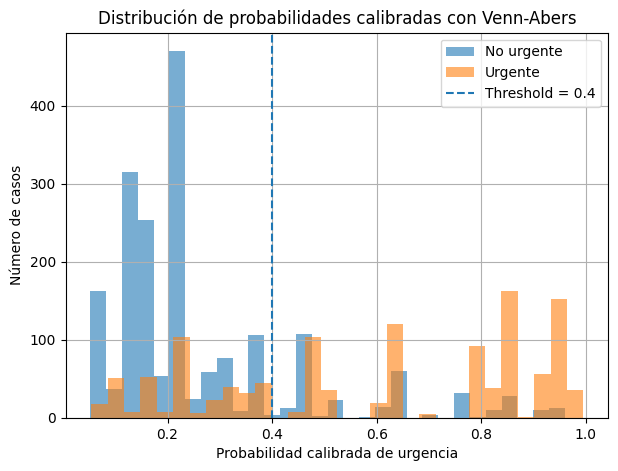

In [ ]:

# DISTRIBUCIÓN DE PROBABILIDADES CALIBRADAS


plt.figure(figsize=(7, 5))

plt.hist(va_probs[valid_labels == 0], bins=30, alpha=0.6, label="No urgente")
plt.hist(va_probs[valid_labels == 1], bins=30, alpha=0.6, label="Urgente")

plt.axvline(threshold, linestyle="--", label=f"Threshold = {threshold}")

plt.xlabel("Probabilidad calibrada de urgencia")
plt.ylabel("Número de casos")
plt.title("Distribución de probabilidades calibradas con Venn-Abers")
plt.legend()
plt.grid(True)

plt.savefig(
    f"{output_dir}/figura_venn_abers_probabilidades_calibradas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

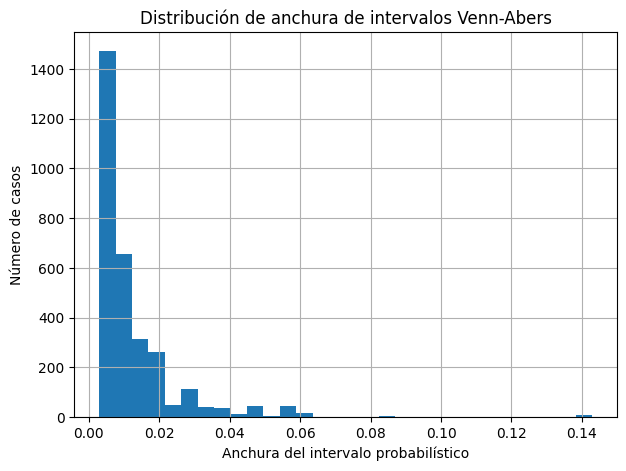

In [ ]:

# DISTRIBUCIÓN DE ANCHURA DE INTERVALOS


plt.figure(figsize=(7, 5))

plt.hist(interval_width, bins=30)

plt.xlabel("Anchura del intervalo probabilístico")
plt.ylabel("Número de casos")
plt.title("Distribución de anchura de intervalos Venn-Abers")
plt.grid(True)

plt.savefig(
    f"{output_dir}/figura_venn_abers_anchura_intervalos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

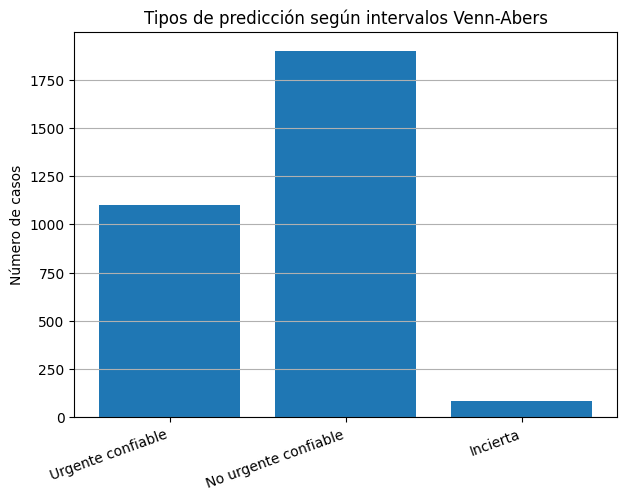

In [ ]:

# TIPOS DE PREDICCIÓN SEGÚN INTERVALOS


counts = pd.Series({
    "Urgente confiable": reliable_urgent.sum(),
    "No urgente confiable": reliable_non_urgent.sum(),
    "Incierta": uncertain.sum()
})

plt.figure(figsize=(7, 5))
plt.bar(counts.index, counts.values)

plt.ylabel("Número de casos")
plt.title("Tipos de predicción según intervalos Venn-Abers")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")

plt.savefig(
    f"{output_dir}/figura_venn_abers_tipos_prediccion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:

# GUARDAR ARRAYS


np.save(f"{output_dir}/valid_labels.npy", valid_labels)
np.save(f"{output_dir}/valid_probs_original.npy", valid_probs)
np.save(f"{output_dir}/valid_probs_venn_abers.npy", va_probs)
np.save(f"{output_dir}/valid_interval_lower.npy", va_lower)
np.save(f"{output_dir}/valid_interval_upper.npy", va_upper)
np.save(f"{output_dir}/valid_interval_width.npy", interval_width)

print("Resultados Venn-Abers guardados correctamente")

Resultados Venn-Abers guardados correctamente


In [ ]:

# Revisión de incertidumbre Venn-Abers basada en anchura


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

output_dir = "/content/drive/MyDrive/TFG/venn_abers_results"

# Cargar resultados ya guardados
valid_labels = np.load(f"{output_dir}/valid_labels.npy")
va_probs = np.load(f"{output_dir}/valid_probs_venn_abers.npy")
va_lower = np.load(f"{output_dir}/valid_interval_lower.npy")
va_upper = np.load(f"{output_dir}/valid_interval_upper.npy")
interval_width = np.load(f"{output_dir}/valid_interval_width.npy")

threshold = 0.4

# Clasificación urgente/no urgente con probabilidad calibrada
va_preds = (va_probs >= threshold).astype(int)

# Analizar distribución de anchuras
percentiles = np.percentile(interval_width, [50, 75, 90, 95, 99])

print("Anchura mínima:", interval_width.min())
print("Anchura máxima:", interval_width.max())
print("Anchura media:", interval_width.mean())
print("Anchura mediana:", np.median(interval_width))
print("P50:", percentiles[0])
print("P75:", percentiles[1])
print("P90:", percentiles[2])
print("P95:", percentiles[3])
print("P99:", percentiles[4])

# Criterio de incertidumbre:
# Se consideran inciertas las predicciones con mayor anchura de intervalo.
# Usamos el percentil 95 para identificar el 5% de casos con mayor incertidumbre.
uncertainty_threshold = np.percentile(interval_width, 95)

uncertain = interval_width > uncertainty_threshold
reliable = interval_width <= uncertainty_threshold

reliable_urgent = reliable & (va_preds == 1)
reliable_non_urgent = reliable & (va_preds == 0)

summary_va_revised = pd.DataFrame({
    "Métrica": [
        "Probabilidad media calibrada",
        "Anchura media del intervalo",
        "Anchura mediana del intervalo",
        "Umbral de incertidumbre P95",
        "Predicciones confiables urgentes",
        "Predicciones confiables no urgentes",
        "Predicciones inciertas"
    ],
    "Valor": [
        va_probs.mean(),
        interval_width.mean(),
        np.median(interval_width),
        uncertainty_threshold,
        reliable_urgent.mean(),
        reliable_non_urgent.mean(),
        uncertain.mean()
    ]
})

summary_va_revised["Valor"] = summary_va_revised["Valor"].round(4)

summary_va_revised.to_csv(
    f"{output_dir}/venn_abers_summary_revised_width_based.csv",
    index=False
)

summary_va_revised

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/TFG/venn_abers_results/valid_labels.npy'

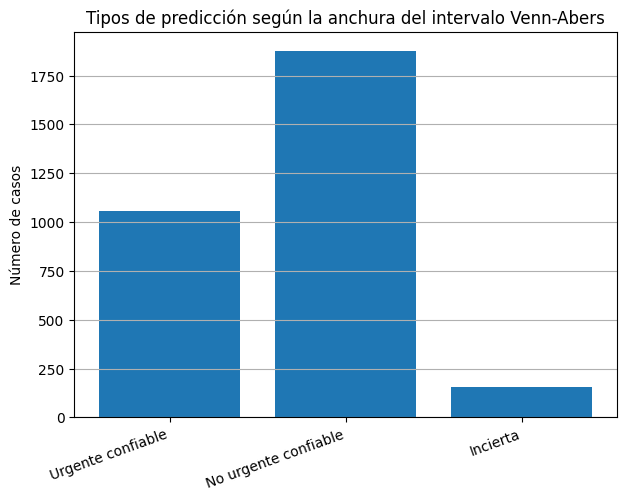

Figura guardada en: /content/drive/MyDrive/TFG/venn_abers_results/figura_venn_abers_tipos_prediccion_revised.png
Urgente confiable       1058
No urgente confiable    1878
Incierta                 155
dtype: int64


In [ ]:

# Figura revisada: tipos de predicción según anchura del intervalo


counts_revised = pd.Series({
    "Urgente confiable": reliable_urgent.sum(),
    "No urgente confiable": reliable_non_urgent.sum(),
    "Incierta": uncertain.sum()
})

plt.figure(figsize=(7, 5))
plt.bar(counts_revised.index, counts_revised.values)

plt.ylabel("Número de casos")
plt.title("Tipos de predicción según la anchura del intervalo Venn-Abers")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")

fig_path = f"{output_dir}/figura_venn_abers_tipos_prediccion_revised.png"

plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada en:", fig_path)
print(counts_revised)

In [ ]:

# Comparación de calibración antes y después de Venn-Abers


from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd

from sklearn.metrics import brier_score_loss, log_loss

# Ruta donde guardaste los resultados de Venn-Abers
output_dir = "/content/drive/MyDrive/TFG/venn_abers_results"

# Cargar etiquetas y probabilidades
valid_labels = np.load(os.path.join(output_dir, "valid_labels.npy"))
valid_probs_original = np.load(os.path.join(output_dir, "valid_probs_original.npy"))
valid_probs_venn_abers = np.load(os.path.join(output_dir, "valid_probs_venn_abers.npy"))

# Calcular métricas antes de calibrar
brier_before = brier_score_loss(valid_labels, valid_probs_original)
logloss_before = log_loss(valid_labels, valid_probs_original)

# Calcular métricas después de calibrar con Venn-Abers
brier_after = brier_score_loss(valid_labels, valid_probs_venn_abers)
logloss_after = log_loss(valid_labels, valid_probs_venn_abers)

# Crear tabla comparativa
calibration_comparison = pd.DataFrame({
    "Métrica": ["Brier Score", "LogLoss"],
    "Antes de Venn-Abers": [brier_before, logloss_before],
    "Después de Venn-Abers": [brier_after, logloss_after]
})

calibration_comparison = calibration_comparison.round(4)

# Guardar tabla
comparison_path = os.path.join(
    output_dir,
    "comparacion_calibracion_antes_despues_venn_abers.csv"
)

calibration_comparison.to_csv(comparison_path, index=False)

print("Tabla guardada en:", comparison_path)

calibration_comparison

Mounted at /content/drive
Tabla guardada en: /content/drive/MyDrive/TFG/venn_abers_results/comparacion_calibracion_antes_despues_venn_abers.csv


,Métrica,Antes de Venn-Abers,Después de Venn-Abers
0,Brier Score,0.1762,0.1597
1,LogLoss,0.7047,0.4935


In [ ]:

# Ejemplos reales de predicciones con Venn-Abers
# Correcto, Falso Negativo y Falso Positivo

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd

output_dir = "/content/drive/MyDrive/TFG/venn_abers_results"

# Cargar resultados por imagen
results_path = os.path.join(output_dir, "valid_venn_abers_predictions.csv")
df_examples = pd.read_csv(results_path)

# Asegurar nombres claros
df_examples["clase_real"] = df_examples["urgent"].map({
    1: "Urgente",
    0: "No urgente"
})

df_examples["clase_predicha"] = df_examples["pred_threshold"].map({
    1: "Urgente",
    0: "No urgente"
})

# Tipo de predicción
def tipo_prediccion(row):
    if row["urgent"] == 1 and row["pred_threshold"] == 1:
        return "Verdadero positivo"
    elif row["urgent"] == 0 and row["pred_threshold"] == 0:
        return "Verdadero negativo"
    elif row["urgent"] == 1 and row["pred_threshold"] == 0:
        return "Falso negativo"
    elif row["urgent"] == 0 and row["pred_threshold"] == 1:
        return "Falso positivo"

df_examples["tipo_prediccion"] = df_examples.apply(tipo_prediccion, axis=1)

# Selección de ejemplos representativos
# 1) Correcto: caso bien clasificado con intervalo estrecho
correct_case = (
    df_examples[df_examples["urgent"] == df_examples["pred_threshold"]]
    .sort_values("anchura_intervalo", ascending=True)
    .head(1)
)

# 2) Falso negativo: urgente clasificado como no urgente
# Escogemos el de mayor anchura para mostrar incertidumbre
false_negative_case = (
    df_examples[df_examples["tipo_prediccion"] == "Falso negativo"]
    .sort_values("anchura_intervalo", ascending=False)
    .head(1)
)

# 3) Falso positivo: no urgente clasificado como urgente
# Opcional, pero útil para comparar errores
false_positive_case = (
    df_examples[df_examples["tipo_prediccion"] == "Falso positivo"]
    .sort_values("anchura_intervalo", ascending=False)
    .head(1)
)

selected_cases = pd.concat([
    correct_case,
    false_negative_case,
    false_positive_case
])

# Tabla limpia para la memoria
selected_cases_table = selected_cases[[
    "Path",
    "clase_real",
    "clase_predicha",
    "tipo_prediccion",
    "prob_original",
    "prob_calibrada_va",
    "intervalo_inferior",
    "intervalo_superior",
    "anchura_intervalo"
]].copy()

selected_cases_table = selected_cases_table.rename(columns={
    "Path": "Imagen",
    "clase_real": "Clase real",
    "clase_predicha": "Clase predicha",
    "tipo_prediccion": "Tipo de predicción",
    "prob_original": "Probabilidad original",
    "prob_calibrada_va": "Probabilidad calibrada Venn-Abers",
    "intervalo_inferior": "Límite inferior",
    "intervalo_superior": "Límite superior",
    "anchura_intervalo": "Anchura del intervalo"
})

selected_cases_table = selected_cases_table.round(4)

# Guardar tabla
examples_path = os.path.join(output_dir, "ejemplos_reales_venn_abers.csv")
selected_cases_table.to_csv(examples_path, index=False)

print("Tabla guardada en:", examples_path)

selected_cases_table

Mounted at /content/drive
Tabla guardada en: /content/drive/MyDrive/TFG/venn_abers_results/ejemplos_reales_venn_abers.csv


,Imagen,Clase real,Clase predicha,Tipo de predicción,Probabilidad original,Probabilidad calibrada Venn-Abers,Límite inferior,Límite superior,Anchura del intervalo
230,CheXpert-v1.0/train/patient01573/study1/view1_...,Urgente,Urgente,Verdadero positivo,1.0000,0.9798,0.9797,0.9826,0.0029
645,CheXpert-v1.0/train/patient04362/study15/view1...,Urgente,No urgente,Falso negativo,0.2633,0.3467,0.3059,0.3684,0.0625
2662,CheXpert-v1.0/train/patient18154/study3/view1_...,No urgente,Urgente,Falso positivo,0.9339,0.6877,0.6438,0.7843,0.1405
